### ResNet Architecture
Build a simple residual block from scratch

In [ ]:
import torch 
import torch.nn as nn 

class ResidualBlock(nn.Module):

    def __init__(self,in_channels,out_channels):
        self.in_channels = in_channels
        self.out_channels = out_channels
        super().__init__()

        #Main path - the part that is F(x)
        self.conv1 = nn.Conv2d(self.in_channels,self.out_channels,kernel_size=3,padding=1)
        self.bn1 = nn.BatchNorm2d(self.out_channels)
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(self.out_channels, self.out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(self.out_channels)

        #IMPORTANT : Skip connection (identity or projection)
        if in_channels != out_channels:
            self.skip = nn.Conv2d(self.in_channels,self.out_channels,kernel_size=1) #1x1
        else:
            self.skip = nn.Identity() #output = input

    def forward(self,x):
        identity = self.skip(x) #save skip connection

        #Main Path : F(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)

        # Residual conn: F(x) + x 
        out = out + identity # element wise addition
        out = self.relu(out) # Last activation

        return out

# Test it
block = ResidualBlock(64, 64)
x = torch.randn(1, 64, 32, 32)
output = block(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")  # Should match!

Part 2: Concept Questions (20 min)

1. Why is torch.max_pool2d(x, 2) in forward less ideal than defining nn.MaxPool2d(2) in __init__? Does it functionally matter?

Functionally, it doesn't. However, having it nn.MaxPool2d(2) in the big convolutional layer helps forward be more readable.

2. You're training on a dataset with class imbalance (90% class A, 10% class B). What problems might arise and how would you address them?

Off the top, our classifier could have a greatly written training loop but still predict everything as class A due to the severe imbalance. Upon creating the datasets and dataloaders I'd make sure to stratify the data. 

THE REAL SOLUTIONS:
    a. Weighted loss: pass a weight parameter. nn.CrossEntropyLoss(weight=torch.tensor([1.0, 9.0])), so it penalizes class B errors more. 
    
    b. Data Augmentation

3. What's one refactoring/optimization technique you learned this week that you'll use at AMD?

Model checkpointing for sure. We'll be training for so many epochs that we will need to save the best model.

# VERY IMPORTANT

# Saturday Practice - End-to-End Project!

## Part 1: Complete Project (60-90 min)

Build a complete transfer learning pipeline on a dataset of your choice.

Choose ONE:

Option A: Flowers102 (102 flower species) - challenging, ~8k images

Option B: Food101 (101 food categories) - harder, ~101k images

Option C: CIFAR-100 (100 classes) - familiar, 50k images


Requirements:

Stage 1: Classifier Training

- Use EfficientNet-B0 or MobileNetV2 (your choice)
- Freeze all, train classifier only
- Proper transforms (ImageNet normalization, data augmentation)
- Train/val/test split
- Track losses, save best model
- Report test accuracy

Stage 2: Fine-tuning

- Load Stage 1 best model
- Unfreeze deeper layers (features[6:] or layer3+layer4)
- Lower learning rate (10x-100x lower)
- Continue training with initial_best_loss from Stage 1
- Report final test accuracy

Stage 3: Save Everything

- Model checkpoint
- Training history (JSON with both stages)
- Test results (JSON)
- Simple inference function

Deliverable: A complete project you could show in a portfolio!

In [1]:
import torch
import torchvision

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import torch.nn as nn

from torch import optim

In [2]:
# 1. Check for MPS (Apple Silicon GPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using MPS (Apple GPU)


In [3]:
# TRANSFORMS
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# DATASETS
train_data = torchvision.datasets.Food101(
    root='./data_food101', 
    split='train', 
    download=False, 
    transform=test_transforms
)

num_classes = len(train_data.classes)
num_channels = train_data[0][0].shape[0]
print(num_channels)

#VAL SPLIT
train_size = int(0.8*len(train_data))
val_size =  len(train_data)-train_size
train_dataset, val_dataset = random_split(train_data,[train_size,val_size])
train_dataset.dataset.transform = train_transforms

test_dataset = torchvision.datasets.Food101(
    root='./data_food101', 
    split='test', 
    download=False, 
    transform=test_transforms
)

# DATALOADERS
batch_size = 32
train_dataloader = DataLoader(dataset=train_dataset,batch_size=batch_size,shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset,batch_size=batch_size,shuffle=False)
test_dataloader = DataLoader(dataset=test_dataset,batch_size=batch_size,shuffle=False)

3


# Let's compare a transfer learning model and my own Food_CNN built from scratch. I'm curious

In [4]:
class Food_CNN(nn.Module):

    def __init__(self,num_channels,num_classes):
        super().__init__()
        self.num_channels=num_channels
        self.num_classes = num_classes

        self.conv_block = nn.Sequential(
            #order: conv, batchnorm2d, relu, maxpool, dropout
            nn.Conv2d(self.num_channels,32,3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        with torch.no_grad():
            dummy = torch.randn((1,3,224,244))
            x = self.conv_block(dummy)
            flat_size = x.view(-1).shape[0]

        self.linear_block = nn.Sequential(
            nn.Linear(flat_size,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.fc = nn.Linear(128,self.num_classes)

    def forward(self,x):
        x = self.conv_block(x)
        x = torch.flatten(x,1)
        x = self.linear_block(x)
        logits = self.fc(x)
        return logits


In [5]:
model_scratch = Food_CNN(num_channels,num_classes)

Now for the transfer learning

In [6]:
#1. Load the model
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

#2. Freeze all layers
for param in model.parameters():
    param.requires_grad = False

#3. take a look at architecture
print(model)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [7]:
#4. Clip output layer to your needs 
orig_num_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(orig_num_feats,num_classes)

#5. If this is exactly how it all played out, then optimize
optimizer = optim.Adam(model.classifier.parameters(),lr=0.001)
loss_fn = nn.CrossEntropyLoss()
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=100,eta_min=1e-6)

In [8]:
class EarlyStopping:

    def __init__(self,patience=5,min_delta=0):
        self.patience = patience #how many epochs to wait after last improvement 
        self.min_delta = min_delta #minimum change to qualify as improvement
        self.counter = 0 
        self.best_loss = None
        self.early_stop = False

    def __call__(self,val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter+=1
            print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                # kill it 
                self.early_stop=True
        else:
            #here is the reset. 
            self.best_loss = val_loss
            self.counter = 0 

In [9]:
def train_loop_class(model, device, optimizer, loss_fn, lr_scheduler, train_dataloader, val_dataloader, train_losses, val_losses, model_save_path, early_stopping, epochs=100, initial_loss=float("inf")):

    best_loss = initial_loss

    for epoch in range(epochs):
        # == TRAINING ==
        model.train()
        train_loss = 0.0

        for X_train, y_train in train_dataloader:
            X_train = X_train.to(device)
            y_train = y_train.to(device)

            optimizer.zero_grad()
            y_pred = model(X_train)
            loss = loss_fn(y_pred, y_train)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)
        if ((epoch + 1) == 1) or ((epoch + 1) % 10 == 0):
            print(f"Epoch {epoch+1} ; Train Loss: {avg_train_loss:.4f}")
        
        # == VAL ==
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for X_val, y_val in val_dataloader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)

                y_pred = model(X_val)
                loss = loss_fn(y_pred, y_val)
                
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        val_losses.append(avg_val_loss)
        if ((epoch + 1) == 1) or ((epoch + 1) % 10 == 0):
            print(f"Epoch {epoch+1} ; Val Loss: {avg_val_loss:.4f}")
        
        # == LR Scheduling ==
        lr_scheduler.step()

        # == SAVE BEST MODEL ==
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(model.state_dict(), model_save_path)

        # == EarlyStopping ==
        if early_stopping is not None:  # just to be safe
            early_stopping(avg_val_loss)
            if early_stopping.early_stop:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    return best_loss

In [10]:
train_losses = []
val_losses = []

Let's train the pre-trained model first

In [11]:
model = model.to(device)
loss_fn = loss_fn.to(device)
best_loss_s1_mvn2 = train_loop_class(model, device, optimizer, loss_fn, lr_scheduler, train_dataloader, val_dataloader, train_losses, val_losses, "best_mvn2.pth", EarlyStopping(15,0), epochs=100, initial_loss=float("inf"))

Epoch 1 ; Train Loss: 2.7232
Epoch 1 ; Val Loss: 2.1300
EarlyStopping counter: 1/15
EarlyStopping counter: 1/15
Epoch 10 ; Train Loss: 1.8219
Epoch 10 ; Val Loss: 1.9018
EarlyStopping counter: 2/15
EarlyStopping counter: 3/15
EarlyStopping counter: 1/15
EarlyStopping counter: 1/15
EarlyStopping counter: 1/15
EarlyStopping counter: 2/15
Epoch 20 ; Train Loss: 1.7855
Epoch 20 ; Val Loss: 1.8848
EarlyStopping counter: 1/15
EarlyStopping counter: 2/15
EarlyStopping counter: 3/15
EarlyStopping counter: 4/15
EarlyStopping counter: 5/15
EarlyStopping counter: 6/15
EarlyStopping counter: 7/15
EarlyStopping counter: 8/15
EarlyStopping counter: 9/15
EarlyStopping counter: 10/15
Epoch 30 ; Train Loss: 1.7602
Epoch 30 ; Val Loss: 1.8997
EarlyStopping counter: 11/15
EarlyStopping counter: 12/15
EarlyStopping counter: 13/15
EarlyStopping counter: 14/15
EarlyStopping counter: 15/15
Early stopping triggered at epoch 34


In [12]:
import matplotlib.pyplot as plt

def plot_results(train_losses,val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f"Training and Validation Loss (Net Total {len(train_losses)} epochs)")
    plt.legend()
    plt.grid(True)
    plt.show()

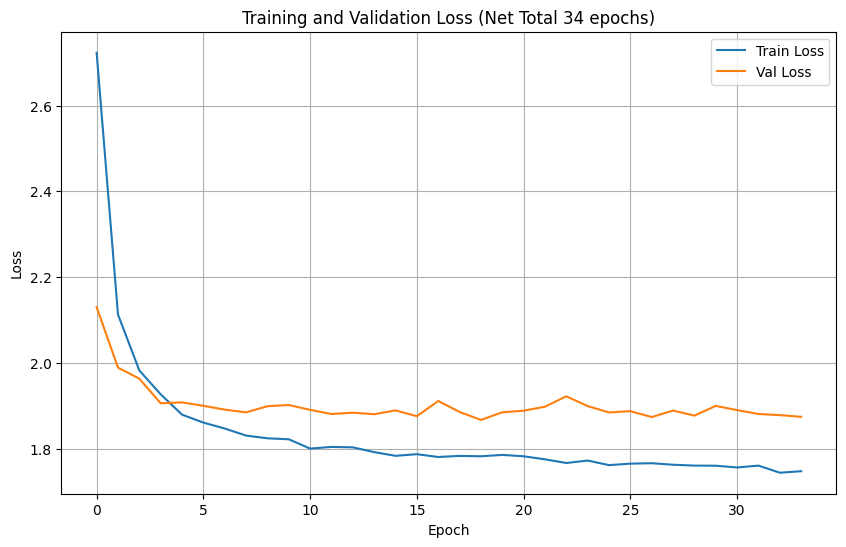

In [13]:
plot_results(train_losses,val_losses)

Session 2 - Monday May 8

In [14]:
print(len(model.features))

19


In [15]:
print(model.features[2])

InvertedResidual(
  (conv): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): Conv2dNormActivation(
      (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=96, bias=False)
      (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (2): Conv2d(96, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (3): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)


There are 19 hidden layers from the start. now that is a lot. 

In [16]:
#1. Load the model
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

#2. Freeze all layers
for param in model.parameters():
    param.requires_grad = False

#3. take a look at architecture - We did this already.
# print(model)

#4. Clip output layer to your needs
orig_num_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(orig_num_feats, num_classes)

#4.a LOAD SAVED MODEL WEIGHTS, otherwise you're toast
model.load_state_dict(torch.load("best_mvn2.pth",weights_only=True))

#4.b The unfreezing you want to do now
#Let's do the last 3 layers, so indices 16,17,18
for param in model.features[16:].parameters():
    param.requires_grad=True

#5. Updated optimizer
optimizer_s2 = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-5)
loss_fn = nn.CrossEntropyLoss()
lr_scheduler_s2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_s2, T_max=100, eta_min=1e-6)

In [17]:
s2_model_save_path = "best_mvn2_s2.pth"
model = model.to(device)
loss_fn = loss_fn.to(device)
best_loss_s2_mvn2 = train_loop_class(model, device, optimizer, loss_fn, lr_scheduler, train_dataloader, val_dataloader, train_losses, val_losses, "best_mvn2_s2.pth", EarlyStopping(15,0.01), epochs=100, initial_loss=best_loss_s1_mvn2)

Epoch 1 ; Train Loss: 1.7141
Epoch 1 ; Val Loss: 1.8937
EarlyStopping counter: 1/15
EarlyStopping counter: 2/15
EarlyStopping counter: 3/15
EarlyStopping counter: 4/15
EarlyStopping counter: 5/15
EarlyStopping counter: 6/15
EarlyStopping counter: 7/15
Epoch 10 ; Train Loss: 1.7146
Epoch 10 ; Val Loss: 1.8990
EarlyStopping counter: 8/15
EarlyStopping counter: 9/15
EarlyStopping counter: 10/15
EarlyStopping counter: 11/15
EarlyStopping counter: 12/15
EarlyStopping counter: 13/15
EarlyStopping counter: 14/15
EarlyStopping counter: 15/15
Early stopping triggered at epoch 17


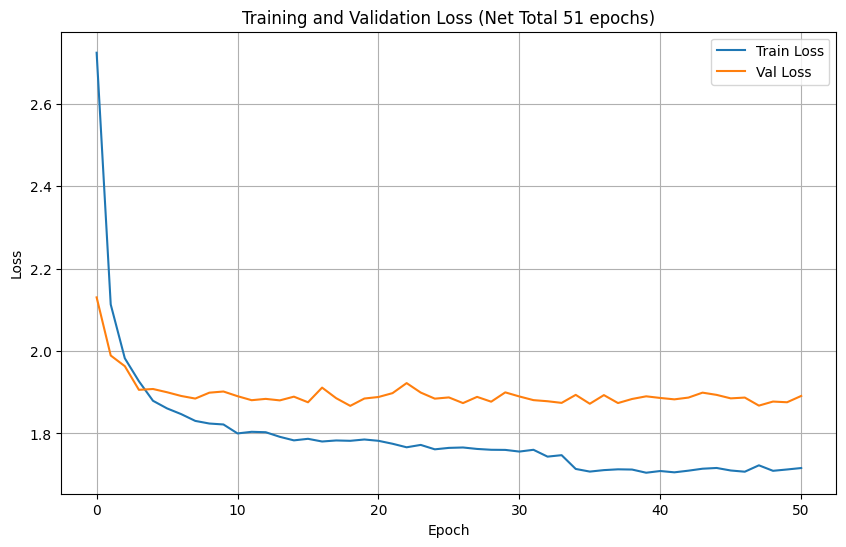

In [18]:
plot_results(train_losses,val_losses)

In [19]:
print("Current best loss is ",best_loss_s2_mvn2)

Current best loss is  1.8670045659260408


# Session 3 - Friday May 8 

- Gonna try a different LR scheduler at a way slower learning rate

In [21]:
#reloading

#1. Load the model
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

#2. Freeze all layers
for param in model.parameters():
    param.requires_grad = False

for param in model.features[16:].parameters():
    param.requires_grad=True

#3. take a look at architecture - We did this already.
# print(model)

#4. Clip output layer to your needs
orig_num_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(orig_num_feats, num_classes)

#4.a LOAD SAVED MODEL WEIGHTS, otherwise you're toast
model.load_state_dict(torch.load("best_mvn2.pth",weights_only=True))

#4.b The unfreezing you want to do now
for param in model.features[10:].parameters():
    param.requires_grad=True

#5. Updated optimizer
# Lower LR + higher weight decay
optimizer_s3 = optim.AdamW(model.parameters(), lr=0.00005, weight_decay=5e-5)
lr_scheduler_s3 = optim.lr_scheduler.CosineAnnealingLR(optimizer_s3, T_max=50, eta_min=1e-7)

early_stopping_s3 = EarlyStopping(15,0.001)

In [ ]:
s3_model_save_path = "best_mvn2_s3.pth"
model = model.to(device)
loss_fn = loss_fn.to(device)
best_loss_s3_mvn2 = train_loop_class(model, device, optimizer, loss_fn, lr_scheduler, train_dataloader, val_dataloader, train_losses, val_losses, s3_model_save_path, early_stopping_s3, epochs=30, initial_loss=best_loss_s2_mvn2)

In [24]:
def test_loop(model,device,loss_fn,test_dataloader):

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X,y in test_dataloader:
            X = X.to(device)
            y = y.to(device)

            y_pred = model(X)
            loss = loss_fn(y_pred,y)

            test_loss += loss.item()

            _,predicted = torch.max(y_pred,1)
            correct+= (predicted==y).sum().item()
            total += y.size(0)

    avg_test_loss = test_loss/len(test_dataloader)
    test_accuracy = correct/total

    return avg_test_loss,test_accuracy

In [ ]:
test_loss, test_acc = test_loop(model,device,loss_fn,test_dataloader)

In [ ]:
print(test_loss,test_acc)

**Sunday Reflection Questions:**

**Part 1: This Week's Learning (10 min)**

1. **You trained Food101 with transfer learning across multiple stages. What was your final test accuracy, and how did it compare to what you'd expect from training from scratch?**

Haven't finished it all yet. 

2. **Explain the complete transfer learning workflow to a fellow student in 5 steps. What's the most important thing they should remember?**

Well before the steps, I'd like to open up with this short analogy: someone who's played table tenns professionally when they were a kid has pre-trained skills that can be translated over to pickleball.
    a. load your pretrained model with its weights that it comes with
    b. freeze all layers, that way it's just going to make a prediction based on what it knows and not learn anything new yet. Only for the first round of training
    c. Explore the model architecture with print(model)
    d. Now that you know how it looks, clip the output layer and fit it to your needs. Make the number of output neurons what you need it to be at the end.
    e. Do some frozen training. See what your loss is.
    f. Now, load your model back exactly the same way, onlt this time, you load the weights you saved from your best model. 
    g. And now, unfreeze some more layers, and then train again with a new optimizer that has a slightly lower learning rate, new lr_scheduler, and same loss_fn if it works well. 
    h. Rinse and repeat and always make sure to prevent overfitting and adjust as you go. 

3. **You used GPU (MPS) for the first time this week. What situations warrant using GPU vs CPU for training?**

Bigger models and especially larget datasets with hella layers warrant GPU training. 

---

**Part 2: Technical Deep Dive (10 min)**

4. **Why do we use progressively lower learning rates (0.001 → 0.0001 → 0.00005) as we unfreeze more layers in transfer learning?**

As we get along the journey to the bottom of the valley, we'd ideally want to take smaller steps so that we don't miss our true lowest point. Smaller learning rate makes the model more careful, which is what we need. 

5. **Looking at your loss plot: train and val losses are close together and both decreasing. What does this tell you about your model? What would be different if you were overfitting?**

It's learning slowly, but well. If it was overfitting, the train loss would be plumetting faster and constantly going down, and the val loss would have reached a lowest point and started going up drastically. Once that happens, the battle is already lost. 

6. **You used `EarlyStopping(15, 0.001)` for Stage 3. Explain why higher patience was needed compared to Stage 1.**

We're unfreezing more layers and are at a more overfit-prone point. We need to be more careful but also more patient because small changes count. 

---